# Spiking Neural Network (SNN) - PyTorch


Using device: cuda

Building model...

Training...
Epoch [1/10] | Loss: 0.2389 | Train Acc: 86.33%
Epoch [2/10] | Loss: 0.1663 | Train Acc: 94.39%
Epoch [3/10] | Loss: 0.0737 | Train Acc: 96.09%
Epoch [4/10] | Loss: 0.0282 | Train Acc: 96.85%
Epoch [5/10] | Loss: 0.0465 | Train Acc: 97.53%
Epoch [6/10] | Loss: 0.0885 | Train Acc: 97.94%
Epoch [7/10] | Loss: 0.0479 | Train Acc: 98.18%
Epoch [8/10] | Loss: 0.0173 | Train Acc: 98.50%
Epoch [9/10] | Loss: 0.0590 | Train Acc: 98.70%
Epoch [10/10] | Loss: 0.0479 | Train Acc: 98.88%

Evaluating on Test Set...
Final Test Accuracy: 97.54%



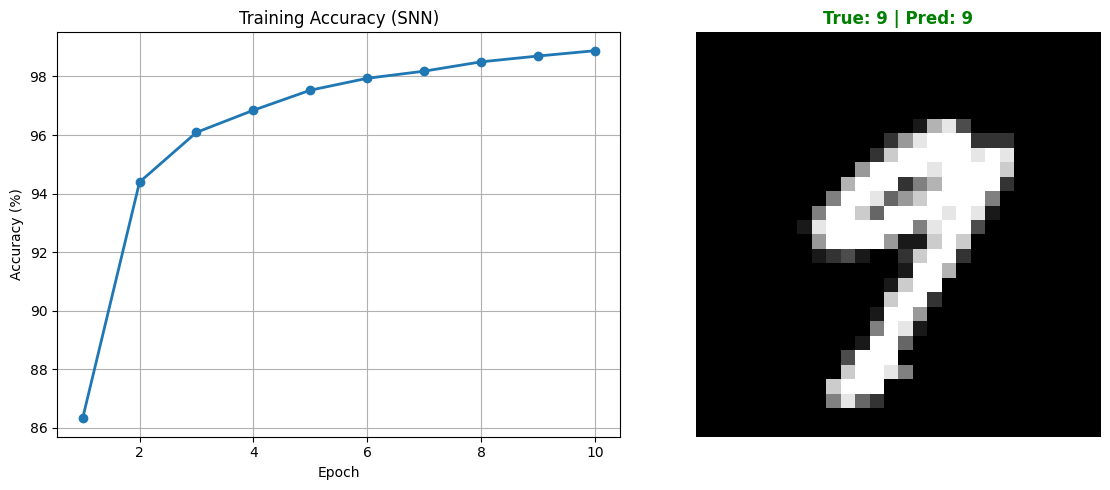

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. SURROGATE GRADIENT & SPIKE FUNCTION
# ============================================================

class SpikeFunction(torch.autograd.Function):
    """
    Step function for forward pass.
    Fast sigmoid surrogate gradient for backward pass to allow learning.
    """
    @staticmethod
    def forward(ctx, input_tensor, threshold=1.0):
        # Fire spike if membrane potential exceeds threshold
        out = (input_tensor >= threshold).float()
        ctx.save_for_backward(input_tensor)
        ctx.threshold = threshold
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (input_tensor,) = ctx.saved_tensors
        threshold = ctx.threshold
        grad = grad_output.clone()

        # Surrogate gradient centered exactly at the threshold (1.0)
        sg = 1.0 / (1.0 + torch.abs(input_tensor - threshold)) ** 2

        return grad * sg, None  # None for the threshold argument

# We alias the apply method to use it easily in our layers
spike_fn = SpikeFunction.apply

# ============================================================
# 2. SNN ARCHITECTURE
# ============================================================

class LIFLayer(nn.Module):
    """Leaky Integrate-and-Fire Layer."""
    def __init__(self, in_features, out_features, decay=0.9, threshold=1.0):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.decay = decay
        self.threshold = threshold
        self.mem = None

    def reset_state(self, batch_size, device):
        """Resets the membrane potential to 0 for a new batch/sequence."""
        self.mem = torch.zeros(batch_size, self.fc.out_features, device=device)

    def forward(self, x):
        # 1. Integrate incoming current (Dense transformation)
        current = self.fc(x)
        self.mem = self.mem * self.decay + current

        # 2. Check for spikes
        spikes = spike_fn(self.mem, self.threshold)

        # 3. Hard reset (membrane potential drops to 0 after spiking)
        # (Note: In TF we used a soft reset, both are valid approaches.
        # Here we use hard reset for variety: mem * (1 - spikes))
        self.mem = self.mem * (1.0 - spikes)

        return spikes

class SNN(nn.Module):
    """2-Layer Spiking Neural Network."""
    def __init__(self, input_size=784, hidden=128, output=10, timesteps=10):
        super().__init__()
        self.timesteps = timesteps

        self.lif1 = LIFLayer(input_size, hidden)
        self.lif2 = LIFLayer(hidden, 64)

        # Final layer doesn't spike; it accumulates to predict classes
        self.fc_out = nn.Linear(64, output)

    def forward(self, x):
        # x shape: (Time, Batch, Features)
        batch_size = x.size(1)
        device = x.device

        # Reset states for the new forward pass sequence
        self.lif1.reset_state(batch_size, device)
        self.lif2.reset_state(batch_size, device)

        spike_sum = torch.zeros(batch_size, self.lif2.fc.out_features, device=device)

        # Unroll the network over time
        for t in range(self.timesteps):
            xt = x[t]
            s1 = self.lif1(xt)
            s2 = self.lif2(s1)
            spike_sum += s2

        # Average spikes over time and pass to output layer to get logits
        out = self.fc_out(spike_sum / self.timesteps)
        return out

# ============================================================
# 3. UTILITIES & DATA LOADING
# ============================================================

def poisson_spike(x, timesteps=10):
    """
    Converts a batch of normalized images into Poisson spike trains.
    Returns shape: (Time, Batch, Features)
    """
    # Flatten images: (batch, 1, 28, 28) -> (batch, 784)
    x = x.view(x.size(0), -1)
    spikes = []

    for _ in range(timesteps):
        # Generate random values directly on the same device as x for speed
        rand = torch.rand_like(x, device=x.device)
        spikes.append((rand < x).float())

    return torch.stack(spikes, dim=0)

def get_dataloaders(batch_size=128):
    """Downloads and prepares MNIST dataloaders."""
    transform = transforms.Compose([transforms.ToTensor()])

    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# ============================================================
# 4. MAIN TRAINING & EVALUATION LOOP
# ============================================================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    timesteps = 10
    train_loader, test_loader = get_dataloaders(batch_size=128)

    print("\nBuilding model...")
    model = SNN(timesteps=timesteps).to(device)

    # CrossEntropyLoss expects raw logits, not softmax outputs
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 10
    train_acc_history = []

    print("\nTraining...")
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Encode continuous input into discrete spikes
            spikes = poisson_spike(images, timesteps=model.timesteps)

            # Forward pass
            outputs = model(spikes)
            loss = criterion(outputs, labels)

            # Backward pass & optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100.0 * correct / total
        train_acc_history.append(acc)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Train Acc: {acc:.2f}%")

    print("\nEvaluating on Test Set...")
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            spikes = poisson_spike(images, timesteps=model.timesteps)

            outputs = model(spikes)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100.0 * correct / total
    print(f"Final Test Accuracy: {test_acc:.2f}%\n")

    # ============================================================
    # 5. VISUALIZATION
    # ============================================================

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- (A) Training Accuracy
    axes[0].plot(range(1, epochs + 1), train_acc_history, marker='o', linewidth=2)
    axes[0].set_title("Training Accuracy (SNN)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].grid(True)

    # ---- (B) Sample Prediction
    # Grab a single batch from the test loader
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    # Process for prediction
    spikes = poisson_spike(images, timesteps=model.timesteps)
    outputs = model(spikes)
    preds = outputs.argmax(dim=1)

    # Pick a random image from the batch
    idx = np.random.randint(0, images.size(0))
    true_label = labels[idx].item()
    pred_label = preds[idx].item()

    # To visualize the spikes, we sum the spikes across time for the chosen image
    # spikes shape: (Time, Batch, 784). Select batch index, sum over time, reshape to 28x28
    spike_img = spikes[:, idx, :].sum(dim=0).view(28, 28).cpu().numpy()

    axes[1].imshow(spike_img, cmap="gray")
    axes[1].set_title(
        f"True: {true_label} | Pred: {pred_label}",
        color="green" if true_label == pred_label else "red",
        fontweight="bold"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()